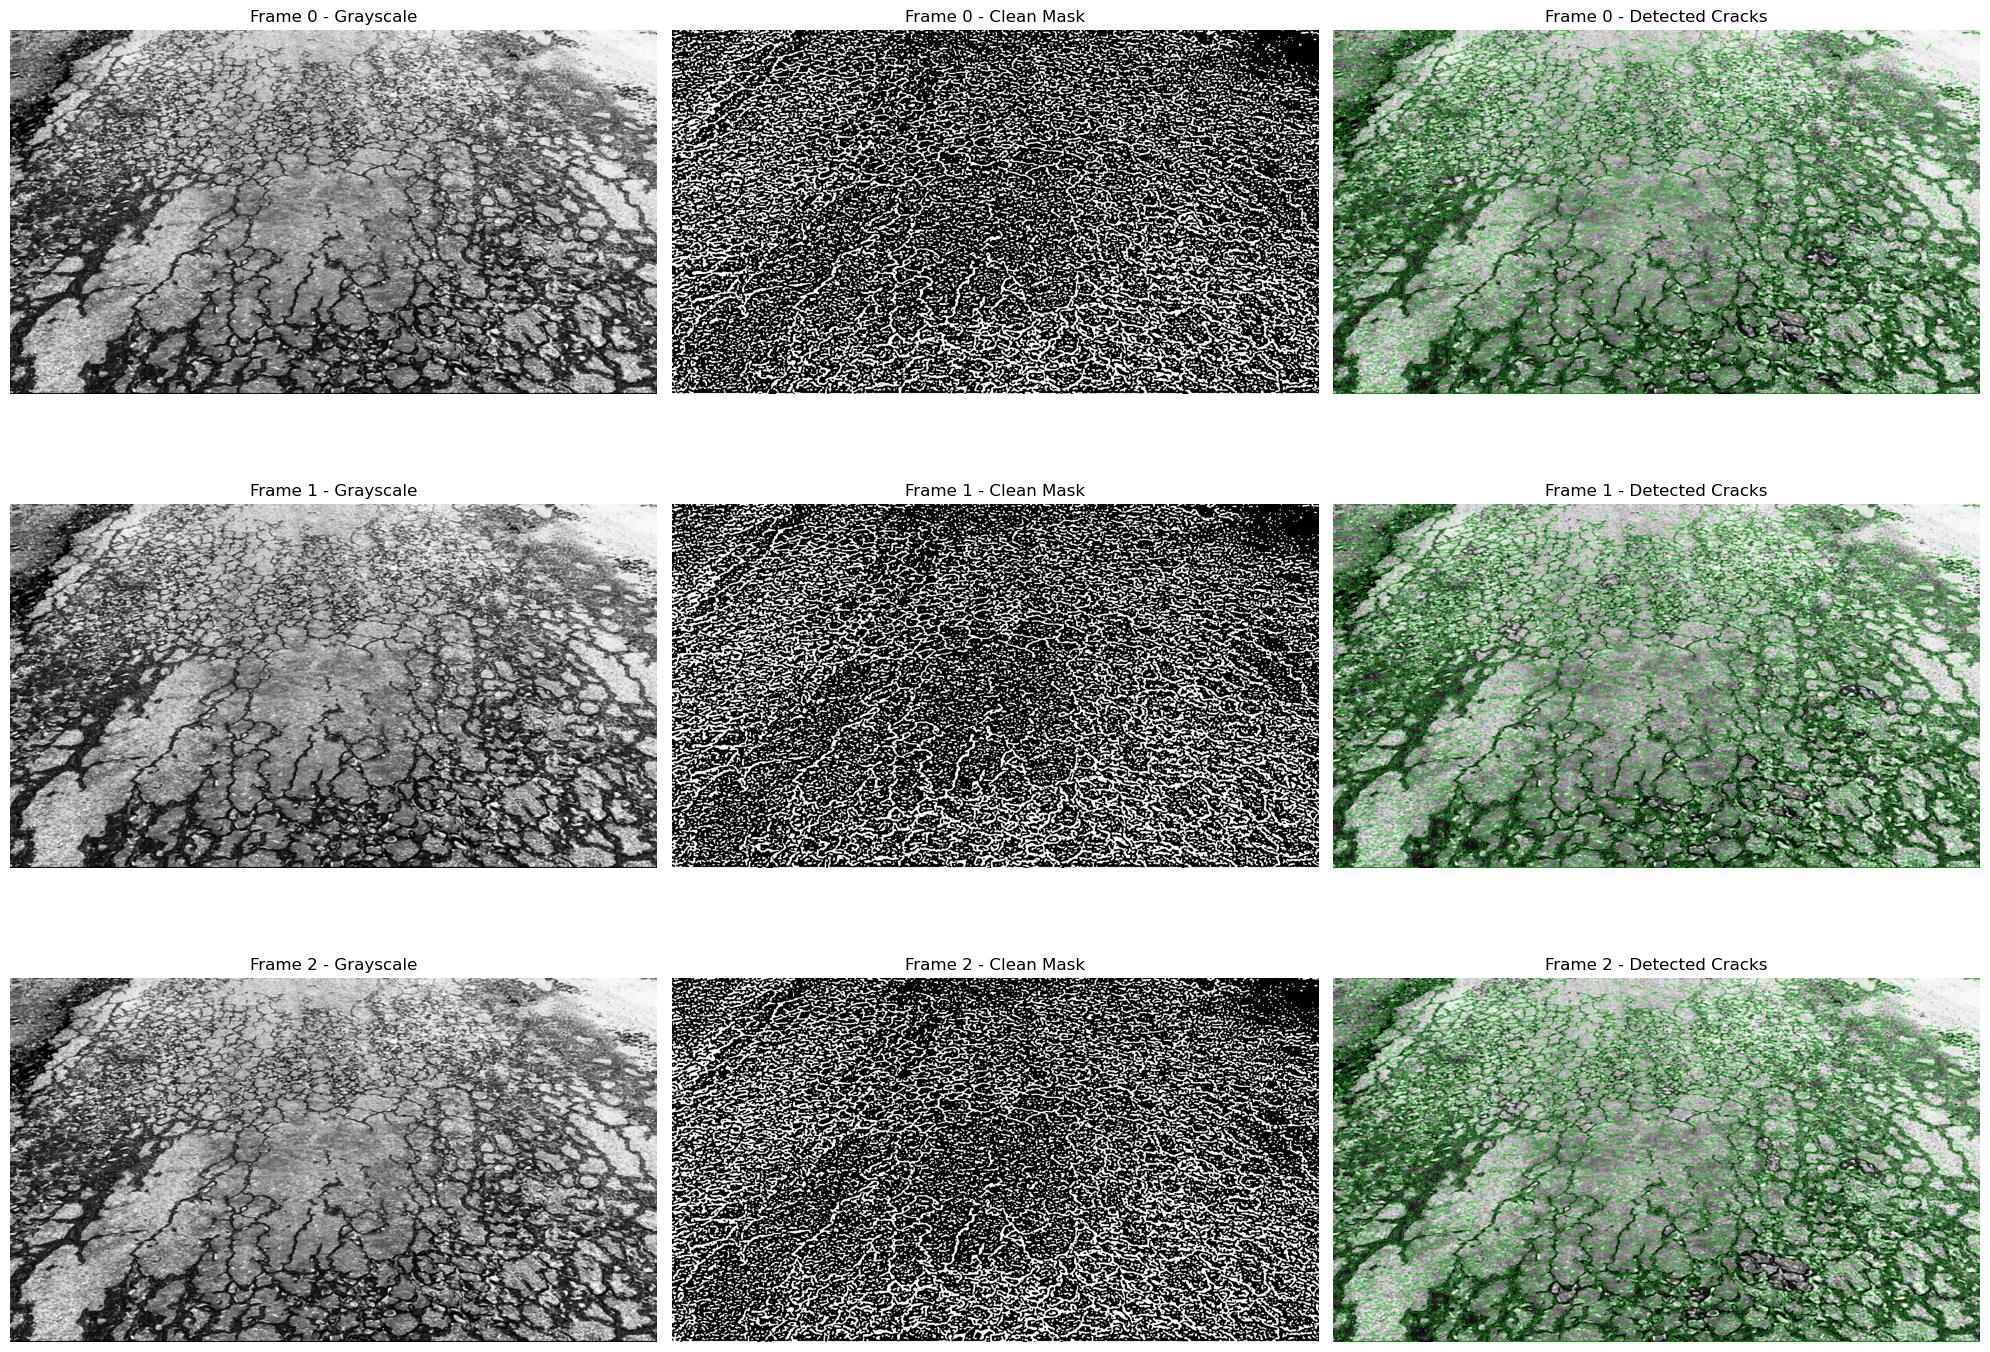

Video saved → alligator_crack_detection.mp4
Done! Processed frames: 122


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

input_video = r"C:\Users\Asanka it Solutions\Desktop\IP_Project (2)\IP_Project\Alligator_crackEnhanced_output.mp4"
output_video = "alligator_crack_detection.mp4"
output_frames = []

cap = cv2.VideoCapture(input_video)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

plot_grays    = []
plot_masks    = []
plot_detected = []
frame_id = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    original = frame.copy()


    # USE ADAPTIVE THRESHOLD
    thresh = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,   
        5       
    )
    edges = cv2.Canny(img, 50, 150)
    binary = cv2.bitwise_or(thresh, edges)

    # REMOVE NOISE
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.dilate(binary, kernel, iterations=1)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

    # FIND CRACK CONTOURS
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    crack_area = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 40:
            crack_area += area
            cv2.drawContours(original, [cnt], -1, (0, 255, 0), 1)

    if frame_id < 3:
        plot_grays.append(img.copy())
        plot_masks.append(clean.copy())
        plot_detected.append(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))

    output_frames.append(original.copy())
    frame_id += 1

cap.release()


plt.figure(figsize=(20, 15))

for i in range(3):
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(plot_grays[i], cmap='gray')
    plt.title(f"Frame {i} - Grayscale")
    plt.axis('off')

    plt.subplot(3, 3, i * 3 + 2)
    plt.imshow(plot_masks[i], cmap='gray')
    plt.title(f"Frame {i} - Clean Mask")
    plt.axis('off')

    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(plot_detected[i])
    plt.title(f"Frame {i} - Detected Cracks")
    plt.axis('off')

plt.tight_layout()
plt.savefig("alligator_crack_plot.png", dpi=100)
plt.show()


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_out = cv2.VideoWriter(output_video, fourcc, fps, (w, h))
for f in output_frames:
    video_out.write(f)
video_out.release()

print(f"Video saved → {output_video}")

cap = cv2.VideoCapture(output_video)
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    cv2.imshow("Alligator Crack Detection", frame)
    if cv2.waitKey(int(1000 / fps)) & 0xFF == ord('q'):
        break
cap.release()
cv2.waitKey(300)
cv2.destroyAllWindows()

print(f"Done! Processed frames: {frame_id}")